In [30]:
import numpy as np 
import pandas as pd

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as DataLoader
from torchvision import datasets,transforms

In [32]:
train='/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray/train'
test='/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray/test'

In [33]:
device=torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [34]:
train_data=datasets.ImageFolder(root=train)
class_names=train_data.classes
num_classes=len(class_names)
print(class_names)


['NORMAL', 'PNEUMONIA']


In [35]:
print(len(train_data))

5232


In [36]:
print(len(datasets.ImageFolder(root=test)))

624


In [37]:
import random

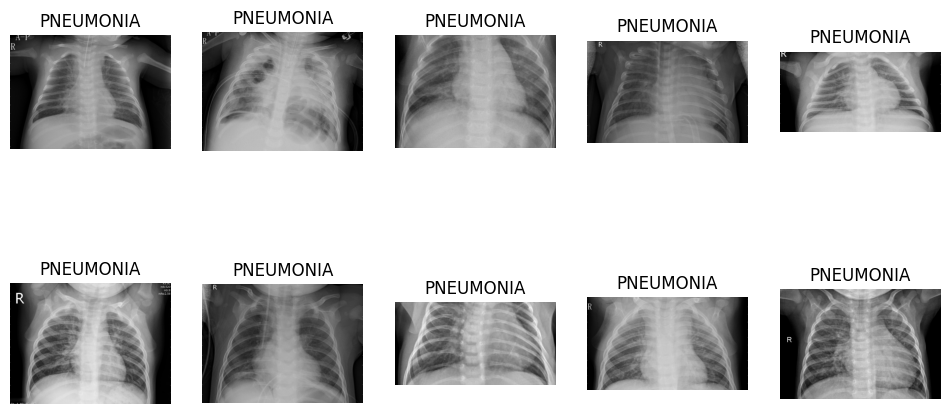

In [38]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# 1️⃣ Define simple transform
transform = transforms.ToTensor()

# 2️⃣ Load dataset
train_data = datasets.ImageFolder(root=train, transform=transform)
class_names = train_data.classes

num_images = 10
random_indices = random.sample(range(len(train_data)), num_images)
# 3️⃣ Display 10 images
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    image, label = train_data[idx]            # get image and label
    img = image.permute(1, 2, 0)              # convert C,H,W -> H,W,C
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')

plt.show()
    

In [39]:
# 

In [76]:
train_aug=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3,contrast=0.2),
    transforms.RandomResizedCrop(224),
    transforms.ToTensor()
    
])

In [77]:
test_transform=transforms.Compose([
transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [78]:
full_train_dataset=datasets.ImageFolder(
    root=train,
    transform=train_aug
)

In [79]:
from torch.utils.data import random_split

In [80]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

In [81]:
train_dataset,val_dataset=random_split(
    full_train_dataset,
    [train_size,val_size]
)

In [82]:
val_dataset.dataset.transform=test_transform

In [83]:
test_dataset=datasets.ImageFolder(
    root=test,
    transform=test_transform
)

In [84]:
from torch.utils.data import DataLoader

In [85]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32)
test_loader=DataLoader(test_dataset,batch_size=32)


In [93]:
import torch
import torch.nn as nn

class MyCNN(nn.Module):
    def __init__(self, num_classes, num_channels=3, input_size=(224,224)):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(num_channels,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )

        dummy_input = torch.zeros(1, num_channels, 224, 224)
        dummy_output = self.features(dummy_input)
        flattened_size = dummy_output.view(1,-1).shape[1]

        print("Flattened size:", flattened_size)

        self.classifier = nn.Sequential(
            nn.Linear(flattened_size,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = torch.flatten(x,1)
        x = self.classifier(x)
        return x

In [94]:
model=MyCNN(num_classes).to(device)



Flattened size: 12544


In [95]:
loss_function=nn.CrossEntropyLoss()

In [96]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [97]:
epochs=50

In [98]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [99]:
for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/50] | Train Loss: 0.2670 | Train Acc: 88.94% | Val Loss: 0.1052 | Val Acc: 96.08%
Epoch [2/50] | Train Loss: 0.1257 | Train Acc: 95.39% | Val Loss: 0.0745 | Val Acc: 97.13%
Epoch [3/50] | Train Loss: 0.1154 | Train Acc: 95.60% | Val Loss: 0.0707 | Val Acc: 97.42%
Epoch [4/50] | Train Loss: 0.0831 | Train Acc: 96.85% | Val Loss: 0.0695 | Val Acc: 97.52%
Epoch [5/50] | Train Loss: 0.0831 | Train Acc: 96.92% | Val Loss: 0.0550 | Val Acc: 98.28%
Epoch [6/50] | Train Loss: 0.0765 | Train Acc: 97.25% | Val Loss: 0.0584 | Val Acc: 97.71%
Epoch [7/50] | Train Loss: 0.0619 | Train Acc: 97.75% | Val Loss: 0.0524 | Val Acc: 98.19%
Epoch [8/50] | Train Loss: 0.0610 | Train Acc: 97.49% | Val Loss: 0.0537 | Val Acc: 98.19%
Epoch [9/50] | Train Loss: 0.0513 | Train Acc: 98.11% | Val Loss: 0.0486 | Val Acc: 98.09%
Epoch [10/50] | Train Loss: 0.0488 | Train Acc: 97.92% | Val Loss: 0.0381 | Val Acc: 98.85%
Epoch [11/50] | Train Loss: 0.0545 | Train Acc: 98.09% | Val Loss: 0.0457 | Val Acc: 98.1

In [100]:
# testing
model.eval()

test_loss = 0
test_correct = 0
test_total = 0
all_preds = []
all_labels = []
with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        loss = loss_function(outputs, labels)   # calculate loss
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

# averages
avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100 * test_correct / test_total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.6485
Test Accuracy: 88.78%


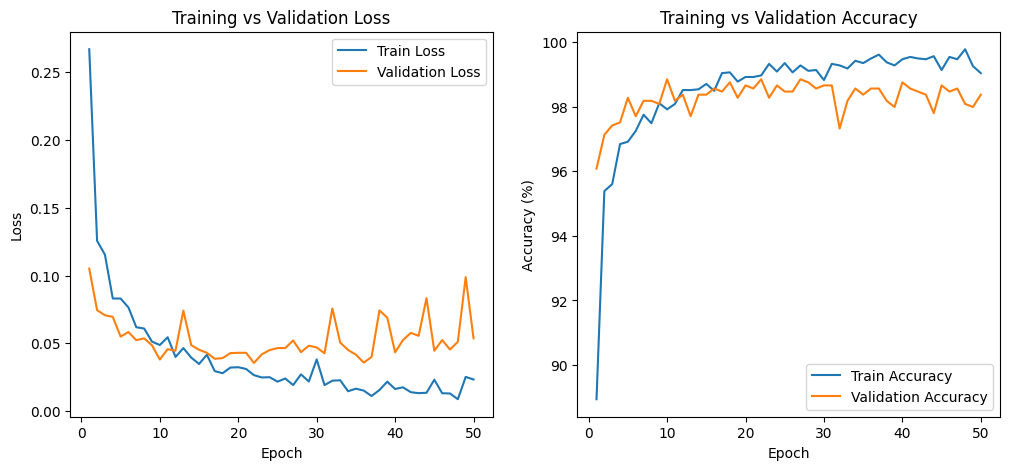

In [101]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs+1)

plt.figure(figsize=(12,5))

# Loss graph
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy graph
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()